In [42]:
!pip install -q transformers datasets accelerate scikit-learn torch pandas ollama underthesea

## Phase 1: Environment Setup and Data Preparation

In [43]:
import torch

# Step 1.2: Hardware Verification
if torch.cuda.is_available():
    print(f"GPU Active: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("GPU is not available. Using CPU. Please enable GPU for faster training.")

GPU Active: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU Memory: 101.97 GB


In [44]:
import pandas as pd
import re

# 1. Load the clauses
clauses = []
try:
    with open("clauses.txt", "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("[Passage"):
                clauses.append(line)
        clauses = clauses[:100000]
except FileNotFoundError:
    print("Error: clauses.txt not found. Please check the file path.")

# 2. Define Regex patterns for each intent in Vietnamese using exact legal phrasing on raw text
# We use (?i) for case insensitivity.
patterns = {
    'Prohibition': re.compile(r'(?i)\b(không được|nghiêm cấm|bị cấm|không có quyền|tuyệt đối không|cấm|chỉ được phép|không có thẩm quyền)\b'),
    'Termination Condition': re.compile(r'(?i)\b(chấm dứt|hủy bỏ|đình chỉ|phạt vi phạm|bồi thường thiệt hại|vô hiệu|thu hồi|hết hiệu lực)\b'),
    'Right': re.compile(r'(?i)\b(có quyền|được phép|có thể|được hưởng|được quyền|được miễn trừ)\b'),
    'Obligation': re.compile(r'(?i)\b(phải|có trách nhiệm|có nghĩa vụ|cam kết|bắt buộc)\b')
}

# 3. Label data using direct Regex matching
labeled_data = []

print(f"Bắt đầu gán nhãn cho {len(clauses)} điều khoản bằng Exact Regex...")

if clauses:
    for clause in clauses:
        assigned_label = 'Obligation' # Default fallback intent

        for label, pattern in patterns.items():
            if pattern.search(clause):
                assigned_label = label
                break # Match highest priority (Prohibition > Termination > Right > Obligation)

        labeled_data.append({'clause': clause, 'label': assigned_label})

# 4. Save results
if labeled_data:
    df = pd.DataFrame(labeled_data)
    df.to_csv("labeled_clauses.csv", index=False, encoding="utf-8-sig")
    print(f"\nHoàn tất! {len(df)} điều khoản đã được gán nhãn và lưu vào 'labeled_clauses.csv'")
    display(df.head(15))
else:
    print("\nKhông có dữ liệu nào để xử lý.")

Bắt đầu gán nhãn cho 100000 điều khoản bằng Exact Regex...

Hoàn tất! 100000 điều khoản đã được gán nhãn và lưu vào 'labeled_clauses.csv'


,clause,label
0,[1] “Điều 2. Địa vị pháp lý của Liên đoàn Luật...,Obligation
1,[2] 1. Liên đoàn Luật sư Việt Nam là tổ chức x...,Obligation
2,[3] 2. Biểu tượng của Liên đoàn Luật sư Việt N...,Obligation
3,[4] 3. Tên giao dịch quốc tế của Liên đoàn Luậ...,Obligation
4,[5] 4. Trụ sở của Liên đoàn Luật sư Việt Nam đ...,Obligation
5,"[1] Điều 7. Tên hợp tác xã, liên hiệp hợp tác xã.",Obligation
6,"[2] 1. Tên hợp tác xã, liên hiệp hợp tác xã đư...",Right
7,"[3] 2. Hợp tác xã, liên hiệp hợp tác xã có thể...",Right
8,"[4] 3. Tên hợp tác xã, liên hiệp hợp tác xã ph...",Obligation
9,[5] 4. Cơ quan đăng ký hợp tác xã có quyền từ ...,Right


In [45]:
from sklearn.model_selection import train_test_split

# Step 1.4: Train/Val/Test Split (80/10/10 Stratified)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")
print("\nClass distribution in train set:")
print(train_df['label'].value_counts())

Training set size: 80000
Validation set size: 10000
Test set size: 10000

Class distribution in train set:
label
Obligation               71556
Right                     3556
Termination Condition     3079
Prohibition               1809
Name: count, dtype: int64


## Phase 2: The Baseline Model (TF-IDF + Logistic Regression)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2.1 & 2.2: TF-IDF Feature Extraction and Logistic Regression Pipeline
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, max_features=5000)),
    ('clf', LogisticRegression(random_state=42, class_weight='balanced'))
])

baseline_pipeline.fit(train_df['clause'], train_df['label'])

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf',
                 LogisticRegression(class_weight='balanced', random_state=42))])

Baseline Classification Report (Test Set):
                       precision    recall  f1-score   support

           Obligation       0.99      0.88      0.93      8945
          Prohibition       0.34      0.88      0.49       226
                Right       0.40      0.86      0.55       444
Termination Condition       0.70      0.96      0.81       385

             accuracy                           0.88     10000
            macro avg       0.61      0.89      0.69     10000
         weighted avg       0.94      0.88      0.90     10000



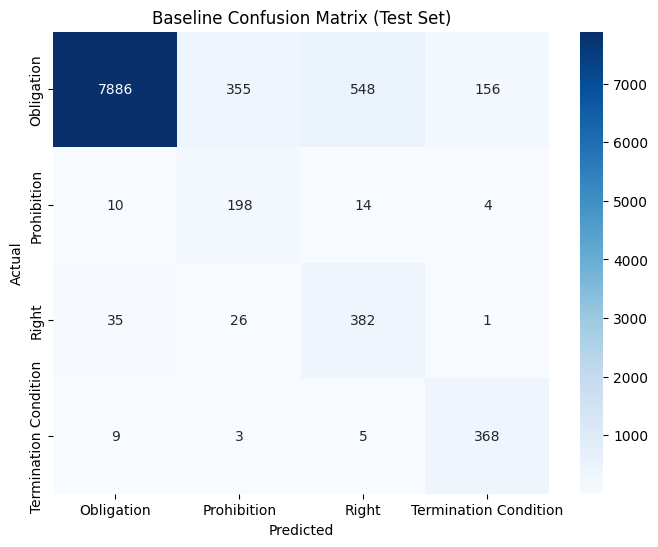

In [47]:
# Step 2.3: Evaluation on Test Set
test_preds = baseline_pipeline.predict(test_df['clause'])

print("Baseline Classification Report (Test Set):")
print(classification_report(test_df['label'], test_preds, zero_division=0))

# Define labels list explicitly
labels_list = ['Obligation', 'Prohibition', 'Right', 'Termination Condition']

# Confusion Matrix
cm = confusion_matrix(test_df['label'], test_preds, labels=labels_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_list, yticklabels=labels_list, cmap='Blues')
plt.title('Baseline Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Phase 3: The Transformer Model (PhoBERT Fine-Tuning)

In [48]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# Step 3.1: Tokenization
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Map labels to integers
label2id = {label: i for i, label in enumerate(labels_list)}
id2label = {i: label for label, i in label2id.items()}

train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['clause', 'label_id']].rename(columns={'label_id': 'label'}))
val_dataset = Dataset.from_pandas(val_df[['clause', 'label_id']].rename(columns={'label_id': 'label'}))
test_dataset = Dataset.from_pandas(test_df[['clause', 'label_id']].rename(columns={'label_id': 'label'}))

def tokenize_function(examples):
    return tokenizer(examples['clause'], padding='max_length', truncation=True, max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [49]:
import torch
# Step 3.2 & 3.3: Model Initialization and Training Configuration
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch", # Changed from save_strategy
    fp16=torch.cuda.is_available(), # Mixed precision
    load_best_model_at_end=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [50]:
# Step 3.4: Execution (Training)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("Starting Transformer Training...")
trainer.train()

Starting Transformer Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.012270,0.008798,0.998800,0.998797
2,0.008149,0.006611,0.999200,0.999200
3,0.002384,0.004817,0.999500,0.999499
4,0.000771,0.004515,0.999600,0.999600
5,0.000567,0.004710,0.999400,0.999400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=25000, training_loss=0.012130808612406254, metrics={'train_runtime': 758.9481, 'train_samples_per_second': 527.045, 'train_steps_per_second': 32.94, 'total_flos': 5.26231560192e+16, 'train_loss': 0.012130808612406254, 'epoch': 5.0})

In [51]:
# Step 3.5: Transformer Evaluation
eval_results = trainer.evaluate()
print(f"Transformer Evaluation Results: {eval_results}")
print("Compare this F1 score to your Baseline model's F1 score above.")

Transformer Evaluation Results: {'eval_loss': 0.004517067223787308, 'eval_accuracy': 0.9996, 'eval_f1': 0.9996001599641897, 'eval_runtime': 5.6059, 'eval_samples_per_second': 1783.822, 'eval_steps_per_second': 111.489, 'epoch': 5.0}
Compare this F1 score to your Baseline model's F1 score above.


Generating predictions for the Transformer model on the test set...


Transformer Classification Report (Test Set):
                       precision    recall  f1-score   support

           Obligation       1.00      1.00      1.00      8945
          Prohibition       1.00      1.00      1.00       226
                Right       1.00      1.00      1.00       444
Termination Condition       1.00      1.00      1.00       385

             accuracy                           1.00     10000
            macro avg       1.00      1.00      1.00     10000
         weighted avg       1.00      1.00      1.00     10000



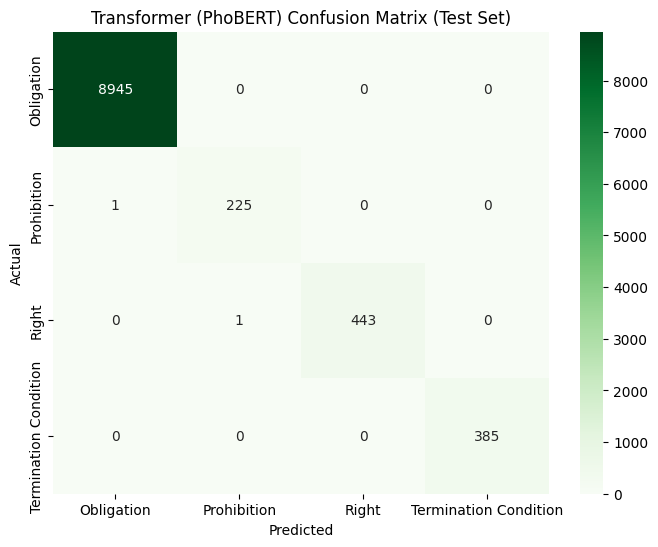

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on the test set
print("Generating predictions for the Transformer model on the test set...")
test_predictions_out = trainer.predict(tokenized_test)
test_pred_class_ids = np.argmax(test_predictions_out.predictions, axis=-1)
test_pred_labels = [id2label[class_id] for class_id in test_pred_class_ids]

# Print Classification Report
print("Transformer Classification Report (Test Set):")
print(classification_report(test_df['label'], test_pred_labels, zero_division=0))

# Confusion Matrix
cm_transformer = confusion_matrix(test_df['label'], test_pred_labels, labels=labels_list)
plt.figure(figsize=(8, 6))
# Using 'Greens' colormap to differentiate from the baseline's 'Blues'
sns.heatmap(cm_transformer, annot=True, fmt='d', xticklabels=labels_list, yticklabels=labels_list, cmap='Greens')
plt.title('Transformer (PhoBERT) Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Phase 4: Inference and Output Formatting

In [53]:
from torch.utils.data import DataLoader
import os
# Step 4.1 & 4.2: Batch Inference and Output Generation
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'intent_classification.txt')

# Create a dataset of unlabelled clauses
unlabelled_dataset = Dataset.from_dict({'clause': clauses})
tokenized_unlabelled = unlabelled_dataset.map(tokenize_function, batched=True)

print("Running inference...")
predictions = trainer.predict(tokenized_unlabelled)
predicted_class_ids = np.argmax(predictions.predictions, axis=-1)
predicted_labels = [id2label[class_id] for class_id in predicted_class_ids]

# Save formatted output
with open(output_file, 'w', encoding='utf-8') as f:
    for clause, label in zip(clauses, predicted_labels):
        # Assignment format requirement: clause followed by label
        f.write(f"{clause} [{label}]\n")

print(f"Predictions saved successfully to {output_file}")

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Running inference...


Predictions saved successfully to output/intent_classification.txt


In [54]:
import numpy as np
import torch
from datasets import Dataset

# Define the custom test sentences with diverse real-world legal examples
test_sentences = [
    # Obligation
    "Bên B phải thanh toán 10.000.000 VNĐ trước ngày 05/5/2024.",

    # Prohibition
    "Người lao động tuyệt đối không được tiết lộ bí mật kinh doanh của công ty.",
    "Nghiêm cấm mọi hành vi sao chép phần mềm khi chưa có sự đồng ý bằng văn bản.",

    # Right
    "Nhà đầu tư có quyền chuyển nhượng cổ phần của mình cho bên thứ ba.",
    "Khách hàng được phép yêu cầu hoàn tiền trong vòng 7 ngày nếu sản phẩm bị lỗi.",

    # Termination Condition
    "Hợp đồng này sẽ tự động chấm dứt khi hai bên hoàn thành mọi thỏa thuận.",
    "Nếu chậm tiến độ quá 30 ngày, hợp đồng sẽ bị hủy bỏ và bên vi phạm phải bồi thường thiệt hại."
]

# Convert to Hugging Face Dataset format
test_dataset = Dataset.from_dict({'clause': test_sentences})

# Tokenize the test sentences
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Run inference
print("Running inference on custom test sentences...")
test_predictions = trainer.predict(tokenized_test)

# Extract logits and compute probabilities
logits = test_predictions.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# Extract predicted classes, map to label names, and get max probability
test_predicted_class_ids = np.argmax(logits, axis=-1)
test_predicted_labels = [id2label[class_id] for class_id in test_predicted_class_ids]
test_predicted_scores = [probs[i, class_id] for i, class_id in enumerate(test_predicted_class_ids)]

# Display the results
print("\n--- INFERENCE RESULTS ---")
for clause, label, score in zip(test_sentences, test_predicted_labels, test_predicted_scores):
    print(f"Clause: {clause}")
    print(f"Predicted Intent: [{label}] (Confidence Score: {score:.4f})\n")

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Running inference on custom test sentences...



--- INFERENCE RESULTS ---
Clause: Bên B phải thanh toán 10.000.000 VNĐ trước ngày 05/5/2024.
Predicted Intent: [Obligation] (Confidence Score: 1.0000)

Clause: Người lao động tuyệt đối không được tiết lộ bí mật kinh doanh của công ty.
Predicted Intent: [Prohibition] (Confidence Score: 0.9998)

Clause: Nghiêm cấm mọi hành vi sao chép phần mềm khi chưa có sự đồng ý bằng văn bản.
Predicted Intent: [Prohibition] (Confidence Score: 0.9998)

Clause: Nhà đầu tư có quyền chuyển nhượng cổ phần của mình cho bên thứ ba.
Predicted Intent: [Right] (Confidence Score: 0.9999)

Clause: Khách hàng được phép yêu cầu hoàn tiền trong vòng 7 ngày nếu sản phẩm bị lỗi.
Predicted Intent: [Right] (Confidence Score: 0.9999)

Clause: Hợp đồng này sẽ tự động chấm dứt khi hai bên hoàn thành mọi thỏa thuận.
Predicted Intent: [Termination Condition] (Confidence Score: 0.9999)

Clause: Nếu chậm tiến độ quá 30 ngày, hợp đồng sẽ bị hủy bỏ và bên vi phạm phải bồi thường thiệt hại.
Predicted Intent: [Termination Conditi

## Phase 5: Hard Cases Comparison (Baseline vs Transformer)
Testing the models against complex semantic structures, implicit meanings, and deceptive trigger words.

In [62]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset

# 1. Define the hard cases and their true expected labels
hard_cases_data = [
    # Obligation
    {"true_label": "Obligation", "clause": "Bên Thuê cam kết hoàn trả nguyên trạng mặt bằng chậm nhất vào ngày làm việc thứ ba kể từ khi hết hạn hợp đồng."},
    {"true_label": "Obligation", "clause": "Để được hưởng các ưu đãi về giá, Bên Mua thanh toán toàn bộ giá trị đơn hàng trong vòng 24 giờ sau khi chốt đơn."},
    {"true_label": "Obligation", "clause": "Ủy ban nhân dân cấp tỉnh có trách nhiệm xây dựng báo cáo về tình hình và dự kiến ký kết, thực hiện thỏa thuận quốc tế nhân danh đơn vị trực thuộc gửi Bộ Ngoại giao."},
    {"true_label": "Obligation", "clause": "Ngay sau khi quyết định truy tố, Viện kiểm sát cấp trên ra quyết định phân công cho Viện kiểm sát cấp dưới thực hành quyền công tố và kiểm sát xét xử."},
    # Prohibition
    {"true_label": "Prohibition", "clause": "Bên B chỉ được phép sử dụng hình ảnh của Bên A cho chiến dịch Mùa Hè 2026, mọi hình thức sử dụng ngoài phạm vi này đều cấu thành hành vi vi phạm."},
    {"true_label": "Prohibition", "clause": "Ngoại trừ trường hợp có văn bản chấp thuận trước từ Hội đồng quản trị, Giám đốc điều hành hoàn toàn không có thẩm quyền ký kết các giao dịch vượt quá 500 triệu đồng."},

    # Right
    {"true_label": "Right", "clause": "Tùy thuộc vào kết quả đánh giá rủi ro hàng quý, Bên A tự quyết định việc tiếp tục hoặc tạm hoãn hạn mức tín dụng đã cấp cho Bên B."},
    {"true_label": "Right", "clause": "Người lao động được miễn trừ mọi trách nhiệm bồi thường đối với các hao mòn tài sản tự nhiên trong quá trình vận hành máy móc."},
    {"true_label": "Right", "clause": " Người sử dụng lao động và người lao động có thể thỏa thuận nội dung thử việc ghi trong hợp đồng lao động hoặc thỏa thuận về thử việc bằng việc giao kết hợp đồng thử việc."},
    # Termination Condition
    {"true_label": "Termination Condition", "clause": "Bên A bảo lưu quyền thu hồi toàn bộ giấy phép và nền tảng phần mềm ngay lập tức nếu phát hiện Bên B rò rỉ mã nguồn."},
    {"true_label": "Termination Condition", "clause": "Thỏa thuận này tự động hết hiệu lực pháp lý và giải phóng các bên khỏi mọi ràng buộc khi Giai đoạn 1 của dự án được nghiệm thu thành công."},
    {"true_label": "Termination Condition", "clause": "Trường hợp cơ quan, người có trách nhiệm thực hiện việc đăng ký thường trú, đăng ký tạm trú không đúng thẩm quyền, không đúng đối tượng và điều kiện theo quy định của Luật này thì cơ quan đã thực hiện việc đăng ký hoặc thủ trưởng cấp trên trực tiếp của cơ quan đã đăng ký có trách nhiệm ra quyết định hủy bỏ việc đăng ký đó."},
]

hard_sentences = [item["clause"] for item in hard_cases_data]
true_labels = [item["true_label"] for item in hard_cases_data]

# 2. Get predictions from the Baseline (Logistic Regression)
baseline_preds = baseline_pipeline.predict(hard_sentences)

# 3. Get predictions from the Transformer (PhoBERT)
hard_dataset = Dataset.from_dict({'clause': hard_sentences})
tokenized_hard = hard_dataset.map(tokenize_function, batched=True)

print("Running Transformer inference on hard cases...")
hard_predictions = trainer.predict(tokenized_hard)

# Calculate probabilities for the Transformer
logits = hard_predictions.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

transformer_class_ids = np.argmax(logits, axis=-1)
transformer_preds = [id2label[class_id] for class_id in transformer_class_ids]
transformer_scores = [probs[i, class_id] for i, class_id in enumerate(transformer_class_ids)]

# 4. Create and display a Comparison Table
comparison_df = pd.DataFrame({
    "Clause": hard_sentences,
    "True Intent": true_labels,
    "Baseline (LR)": baseline_preds,
    "Transformer (PhoBERT)": transformer_preds,
    "PhoBERT Confidence": [f"{score:.4f}" for score in transformer_scores]
})

# Display the dataframe without styling
display(comparison_df)

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

Running Transformer inference on hard cases...


,Clause,True Intent,Baseline (LR),Transformer (PhoBERT),PhoBERT Confidence
0,Bên Thuê cam kết hoàn trả nguyên trạng mặt bằn...,Obligation,Termination Condition,Obligation,1.0000
1,"Để được hưởng các ưu đãi về giá, Bên Mua thanh...",Obligation,Right,Right,0.9999
2,Ủy ban nhân dân cấp tỉnh có trách nhiệm xây dự...,Obligation,Obligation,Obligation,1.0000
3,"Ngay sau khi quyết định truy tố, Viện kiểm sát...",Obligation,Obligation,Obligation,1.0000
4,Bên B chỉ được phép sử dụng hình ảnh của Bên A...,Prohibition,Obligation,Prohibition,0.9998
5,Ngoại trừ trường hợp có văn bản chấp thuận trư...,Prohibition,Obligation,Prohibition,0.9998
6,Tùy thuộc vào kết quả đánh giá rủi ro hàng quý...,Right,Obligation,Obligation,1.0000
7,Người lao động được miễn trừ mọi trách nhiệm b...,Right,Prohibition,Right,0.9999
8,Người sử dụng lao động và người lao động có t...,Right,Right,Right,0.9999
9,Bên A bảo lưu quyền thu hồi toàn bộ giấy phép ...,Termination Condition,Termination Condition,Termination Condition,0.9999
